Load NASA Exoplanet Dataset

In [3]:
import pandas as pd
import numpy as np

csv_path = "Dataset_exoplanet.csv"

df = pd.read_csv(csv_path, comment="#")

print("Rows:", len(df), "| Columns:", len(df.columns))
df.head()


Rows: 6053 | Columns: 84


,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007,Xinglong Station,0,323.21000,0.06000,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20000,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008,Okayama Astrophysical Observatory,0,186.76000,0.11000,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826
3,14 Her b,14 Her,1,2,Radial Velocity,2002,W. M. Keck Observatory,0,1765.03890,1.67709,...,-0.0073,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996,Multiple Observatories,0,798.50000,1.00000,...,-0.0111,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603


Dataset Information and Missing Values Analysis

In [ ]:
df.info()

missing_values = df.isnull().sum()
print("\nMissing values per column:\n")
print(missing_values)

print("\nMissing Value Percentage:\n")
print((missing_values / len(df)) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6053 entries, 0 to 6052
Data columns (total 84 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6053 non-null   object 
 1   hostname         6053 non-null   object 
 2   sy_snum          6053 non-null   int64  
 3   sy_pnum          6053 non-null   int64  
 4   discoverymethod  6053 non-null   object 
 5   disc_year        6053 non-null   int64  
 6   disc_facility    6053 non-null   object 
 7   pl_controv_flag  6053 non-null   int64  
 8   pl_orbper        5737 non-null   float64
 9   pl_orbpererr1    5246 non-null   float64
 10  pl_orbpererr2    5246 non-null   float64
 11  pl_orbperlim     5737 non-null   float64
 12  pl_orbsmax       5750 non-null   float64
 13  pl_orbsmaxerr1   3806 non-null   float64
 14  pl_orbsmaxerr2   3806 non-null   float64
 15  pl_orbsmaxlim    5751 non-null   float64
 16  pl_rade          6003 non-null   float64
 17  pl_radeerr1   

Data Cleaning: Remove High-Null Columns, Missing Key Values, and Invalid Entries

In [17]:
threshold = len(df) * 0.60
df = df.dropna(axis=1, thresh=threshold)
print("After removing high-null columns:", df.shape)

df = df[
    (df["pl_rade"] > 0) &
    (df["pl_orbsmax"] > 0) &
    (df["pl_eqt"] > 0) &
    (df["st_teff"] > 0)
]
print("After removing non-physical values:", df.shape)

df.reset_index(drop=True, inplace=True)
print("\nFinal Cleaned Dataset Shape:", df.shape)

df.head()


After removing high-null columns: (4385, 71)
After removing non-physical values: (4385, 71)

Final Cleaned Dataset Shape: (4385, 71)


,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,1RXS J160929.1-210524 b,1RXS J160929.1-210524,1,1,Imaging,2008,Gemini Observatory,0,NaN,NaN,...,-1.307,12.618,0.069,-0.069,8.916,0.021,-0.021,12.0572,0.002275,-0.002275
1,2M0437 b,2MASS J04372171+2651014,1,1,Imaging,2021,Subaru Telescope,0,NaN,NaN,...,-1.174,16.186,1.133,-1.133,10.386,0.018,-0.018,14.3374,0.000772,-0.000772
2,2MASS J01225093-2439505 b,2MASS J01225093-2439505,1,1,Imaging,2013,W. M. Keck Observatory,0,NaN,NaN,...,-0.086,14.244,0.074,-0.074,9.198,0.026,-0.026,12.9025,0.001151,-0.001151
3,2MASS J03590986+2009361 b,2MASS J03590986+2009361,1,1,Imaging,2024,European Space Agency (ESA) Gaia Satellite,0,NaN,NaN,...,-2.233,NaN,NaN,NaN,12.533,0.028,-0.028,16.9967,0.001082,-0.001082
4,2MASS J11550485-7919108 b,2MASS J11550485-7919108,1,1,Imaging,2024,European Space Agency (ESA) Gaia Satellite,0,NaN,NaN,...,-0.596,16.957,0.309,-0.309,10.079,0.021,-0.021,14.8180,0.001725,-0.001725


In [18]:
df.to_csv("Cleaned_Exoplanet_Dataset.csv", index=False)

Summary Statistics of Numerical Features

In [19]:
df.describe()

,sy_snum,sy_pnum,disc_year,pl_controv_flag,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,pl_orbsmaxlim,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
count,4385.000000,4385.000000,4385.000000,4385.000000,4.349000e+03,3.873000e+03,3.873000e+03,4349.000000,4385.000000,4385.0,...,4269.000000,4375.000000,4371.000000,4366.000000,4380.000000,4350.000000,4343.000000,4349.000000,4348.000000,4348.000000
mean,1.083922,1.796351,2017.086203,0.002737,9.743122e+04,1.232015e+05,-2.792247e+04,-0.000460,9.351064,0.0,...,-16.200362,13.497091,0.110094,-0.110135,11.381434,0.031027,-0.031047,13.234904,0.000518,-0.000518
std,0.310667,1.182014,3.985873,0.052247,6.098591e+06,7.552566e+06,1.609191e+06,0.021442,191.643139,0.0,...,34.329449,2.212453,0.130334,0.130381,2.140494,0.152423,0.152545,2.182560,0.000855,0.000855
min,1.000000,1.000000,1996.000000,0.000000,1.768913e-01,0.000000e+00,-1.000000e+08,-1.000000,0.005000,0.0,...,-1073.720000,3.850000,0.001000,-1.133000,2.237000,0.011000,-9.995000,3.820150,0.000112,-0.017417
25%,1.000000,1.000000,2014.000000,0.000000,3.922804e+00,7.700000e-06,-1.900000e-04,0.000000,0.047700,0.0,...,-18.020000,12.246000,0.044500,-0.137000,10.171750,0.020000,-0.032000,12.003100,0.000258,-0.000526
50%,1.000000,1.000000,2016.000000,0.000000,8.457463e+00,3.500000e-05,-3.515000e-05,0.000000,0.078400,0.0,...,-6.335000,13.957000,0.092000,-0.092000,11.974000,0.023000,-0.023000,13.739700,0.000362,-0.000362
75%,1.000000,2.000000,2021.000000,0.000000,2.054982e+01,1.900000e-04,-7.657000e-06,0.000000,0.145600,0.0,...,-1.364500,15.189500,0.137000,-0.045225,13.053000,0.032000,-0.020000,14.953500,0.000526,-0.000258
max,4.000000,8.000000,2025.000000,1.000000,4.020000e+08,4.700000e+08,0.000000e+00,0.000000,7506.000000,0.0,...,-0.000350,20.150000,1.133000,-0.001000,15.548000,9.995000,-0.011000,18.912000,0.017417,-0.000112


Data Analysis Using Visualizations

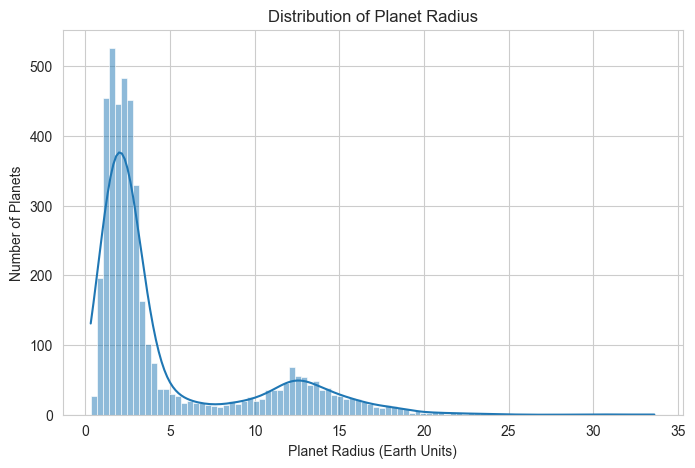

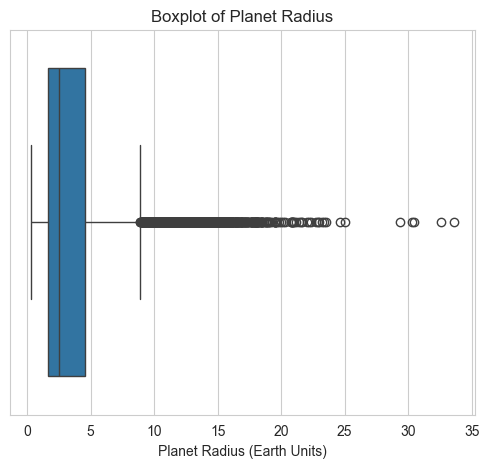

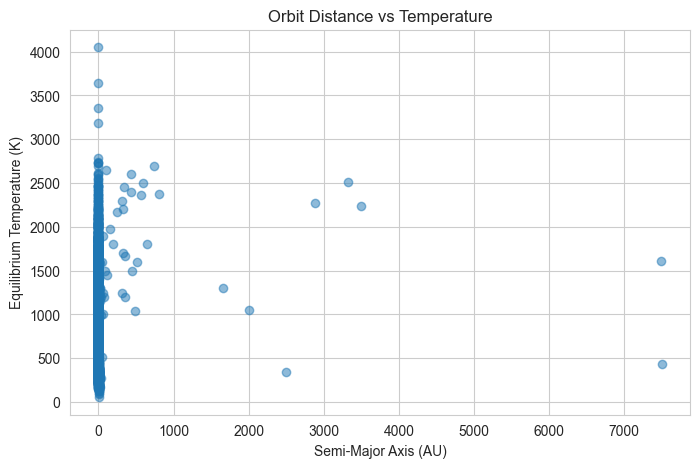

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Histogram 
plt.figure(figsize=(8,5))
sns.histplot(df['pl_rade'], kde=True)
plt.title("Distribution of Planet Radius")
plt.xlabel("Planet Radius (Earth Units)")
plt.ylabel("Number of Planets")
plt.show()

# Boxplot
plt.figure(figsize=(6,5))
sns.boxplot(x=df['pl_rade'])
plt.title("Boxplot of Planet Radius")
plt.xlabel("Planet Radius (Earth Units)")
plt.show()

# Scatter Plot 
plt.figure(figsize=(8,5))
plt.scatter(df['pl_orbsmax'], df['pl_eqt'], alpha=0.5)
plt.title("Orbit Distance vs Temperature")
plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Equilibrium Temperature (K)")
plt.show()


 Identify Categorical Columns for Encoding

In [10]:
df.select_dtypes(include=['object']).columns


Index(['pl_name', 'hostname', 'discoverymethod', 'disc_facility',
       'pl_bmassprov', 'st_metratio', 'rastr', 'decstr'],
      dtype='object')

In [ ]:
"st_spectype" in df.columns

False